# Day 5: Stochastic Optimisation
Real world is often not deterministic. Everything has an uncertainity in it. Stochastic optimisation aims to factor in that uncertainity in our models to make them more robust and accurate to real world scenario. 

In [3]:
import numpy as np
import pandas as pd

np.random.seed(42)

# Having 2 to 10 trucks
truck_options = range(2, 11)
# Testing 500 uncertain scenarios for each fleet size. 
n_scenarios = 500

# Array for storing results
results = []

# loop over fleet size
for n_trucks in truck_options:

    # Array for storing production from 500 scenarios for one fleet size
    scenario_production = []
    scenario_queue_penalty = []

    # loop over number of scenarios for one fleet size
    for s in range(n_scenarios):

        # Random productivity per truck and congestion penalty
        productivity_per_truck = np.random.normal(850, 90)

        # Congestion penalty starts after n=5
        congestion_penalty = max(0, n_trucks - 5) * np.random.normal(70, 20)

        # breakdown chances 15% with random severity
        breakdown_loss = np.random.binomial(1, 0.15) * np.random.uniform(200, 700)

        # Final produciton after accounting for penalties in one test scenario
        production = n_trucks * productivity_per_truck - congestion_penalty - breakdown_loss

        # Storing production and congestion penalty values
        scenario_production.append(production)
        scenario_queue_penalty.append(congestion_penalty)
        
    # Adding average and 10th percentile production, and mean congestion penalty to list results, in dict structures
    results.append({
        "n_trucks": n_trucks,
        "mean_production": np.mean(scenario_production),
        "p10_production": np.percentile(scenario_production, 10),
        "mean_congestion_penalty": np.mean(scenario_queue_penalty)
    })
# Storing the list in a dataframe and printing it
df = pd.DataFrame(results)

print(df)

# Finding the highest mean and p10 production and printing it
best_mean = df.loc[df["mean_production"].idxmax()]
best_risk = df.loc[df["p10_production"].idxmax()]

print("Best by average production:")
print(best_mean)

print("Best by downside-risk production, P10:")
print(best_risk)

   n_trucks  mean_production  p10_production  mean_congestion_penalty
0         2      1626.222786     1224.304771                 0.000000
1         3      2488.463795     2071.131245                 0.000000
2         4      3339.149056     2837.025152                 0.000000
3         5      4195.984245     3590.253413                 0.000000
4         6      4965.411351     4294.983572                71.150930
5         7      5781.435206     5036.151369               140.261767
6         8      6529.232786     5618.050760               209.124619
7         9      7365.542513     6248.801626               282.425520
8        10      8081.175627     6903.798174               350.568313
Best by average production:
n_trucks                     10.000000
mean_production            8081.175627
p10_production             6903.798174
mean_congestion_penalty     350.568313
Name: 8, dtype: float64
Best by downside-risk production, P10:
n_trucks                     10.000000
mean_productio

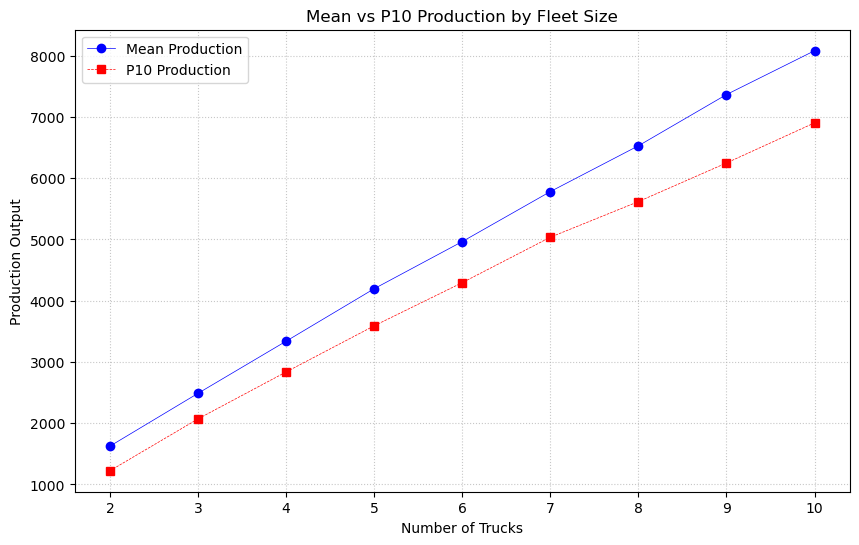

In [4]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(10, 6))

# Plot Mean Production
plt.plot(df["n_trucks"], df["mean_production"], label="Mean Production", marker='o', linewidth=0.5, color='blue')

# Plot P10 Production
plt.plot(df["n_trucks"], df["p10_production"], label="P10 Production", marker='s', linewidth=0.5, linestyle='--', color='red')

# Add labels and formatting
plt.title("Mean vs P10 Production by Fleet Size")
plt.xlabel("Number of Trucks")
plt.ylabel("Production Output")
plt.xticks(df["n_trucks"]) # Ensures only whole truck numbers show on the x-axis
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# Display the plot
plt.show()

### Observation
I tried different maximum fleet sizes, but the optimization always selected the highest number of trucks. This suggests the model is missing a strong enough opposing effect to create a real trade-off.
### Change
One possible issue is the congestion equation — it is linear, so congestion grows too slowly compared to production. In the following part, this was improved using a quadratic congestion equation to model realistic congestion buildup. 
Also, the totlal number of trucks were increased to have a view of the plateau formed. 


In [10]:
import numpy as np
import pandas as pd

np.random.seed(42)

# Having 2 to 10 trucks
truck_options = range(2, 16)
# Testing 500 uncertain scenarios for each fleet size. 
n_scenarios = 500

# Array for storing results
results = []

# loop over fleet size
for n_trucks in truck_options:

    # Array for storing production from 500 scenarios for one fleet size
    scenario_production = []
    scenario_queue_penalty = []

    # loop over number of scenarios for one fleet size
    for s in range(n_scenarios):

        # Random productivity per truck and congestion penalty
        productivity_per_truck = np.random.normal(850, 90)

        # Congestion penalty starts after n=5
        congestion_penalty = max(0, n_trucks - 5)**2 * np.random.normal(70, 20)

        # breakdown chances 15% with random severity
        breakdown_loss = np.random.binomial(1, 0.15) * np.random.uniform(200, 700)

        # Final produciton after accounting for penalties in one test scenario
        production = n_trucks * productivity_per_truck - congestion_penalty - breakdown_loss

        # Storing production and congestion penalty values
        scenario_production.append(production)
        scenario_queue_penalty.append(congestion_penalty)
        
    # Adding average and 10th percentile production, and mean congestion penalty to list results, in dict structures
    results.append({
        "n_trucks": n_trucks,
        "mean_production": np.mean(scenario_production),
        "p10_production": np.percentile(scenario_production, 10),
        "mean_congestion_penalty": np.mean(scenario_queue_penalty)
    })
# Storing the list in a dataframe and printing it
df = pd.DataFrame(results)

print(df)

# Finding the highest mean and p10 production and printing it
best_mean = df.loc[df["mean_production"].idxmax()]
best_risk = df.loc[df["p10_production"].idxmax()]

print("Best by average production:")
print(best_mean)

print("Best by downside-risk production, P10:")
print(best_risk)

    n_trucks  mean_production  p10_production  mean_congestion_penalty
0          2      1626.222786     1224.304771                 0.000000
1          3      2488.463795     2071.131245                 0.000000
2          4      3339.149056     2837.025152                 0.000000
3          5      4195.984245     3590.253413                 0.000000
4          6      4965.411351     4294.983572                71.150930
5          7      5641.173439     4878.385970               280.523533
6          8      6110.983549     5151.015020               627.373856
7          9      6518.265954     5277.661088              1129.702079
8         10      6678.902375     5362.975007              1752.841565
9         11      6719.580477     5118.319023              2561.923558
10        12      6709.087326     4827.175927              3455.035305
11        13      6615.060095     4528.385671              4420.308012
12        14      6196.938345     3229.057230              5594.287007
13    

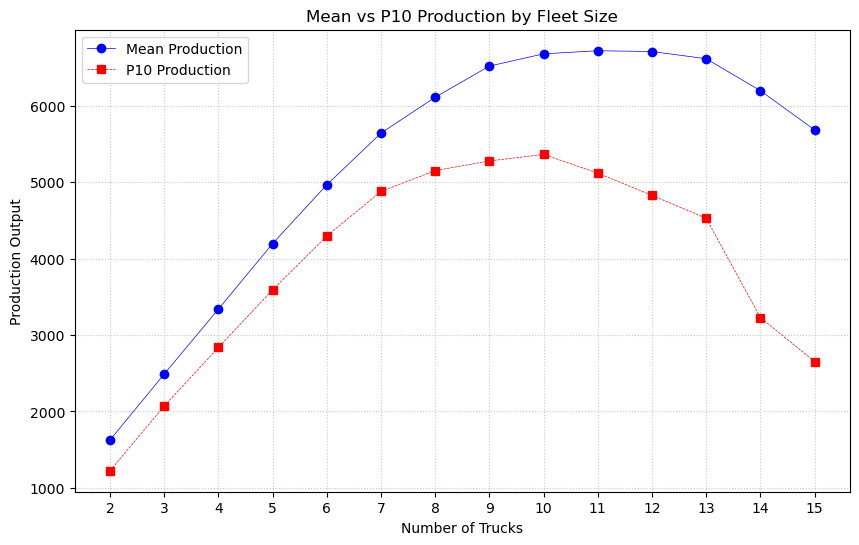

In [11]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(10, 6))

# Plot Mean Production
plt.plot(df["n_trucks"], df["mean_production"], label="Mean Production", marker='o', linewidth=0.5, color='blue')

# Plot P10 Production
plt.plot(df["n_trucks"], df["p10_production"], label="P10 Production", marker='s', linewidth=0.5, linestyle='--', color='red')

# Add labels and formatting
plt.title("Mean vs P10 Production by Fleet Size")
plt.xlabel("Number of Trucks")
plt.ylabel("Production Output")
plt.xticks(df["n_trucks"]) # Ensures only whole truck numbers show on the x-axis
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# Display the plot
plt.show()

## Observation
The updated stochastic model showed a realistic production-congestion tradeoff. Both mean and P10 production increased initially with fleet size, but eventually plateaued and declined due to the stronger quadratic congestion effect. Mean production peaked at a higher truck count because it reflects average performance, while P10 production peaked earlier and dropped more sharply, indicating increasing operational risk and instability at larger fleet sizes. This demonstrates that maximizing average production alone may lead to fragile decisions, whereas P10-based analysis helps identify more robust and reliable fleet sizes under uncertainty.
